In [1]:
from time import time
from itertools import product
from tqdm import tqdm_notebook as tqdm
from APmodels import *
# from peaks import *

In [2]:
ti, tf, tstep = 0, 30e-3, 1e-5
T = np.arange(ti, tf, tstep)

X0 = [-8.07890166e+01,  2.80792445e-02,  6.83206923e-01,  1.22050351e-01]
nrnmfb = hhMFB(X0, T)
nrnmfb.solve()

X0 = [-6.49963794e+01, 5.29550868e-02, 5.95994055e-01, 3.17732397e-01]
nrnhh = HH(X0, T)
nrnhh.solve()

## Compare AP from HH and MFB model

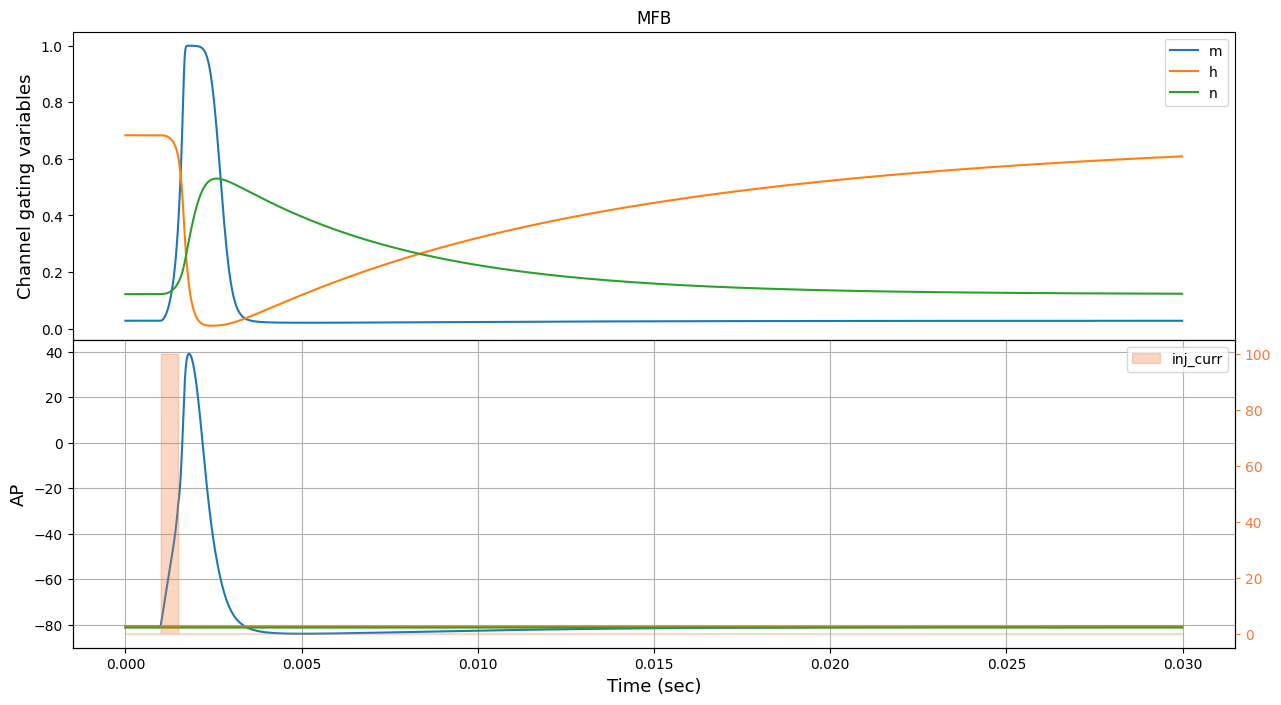

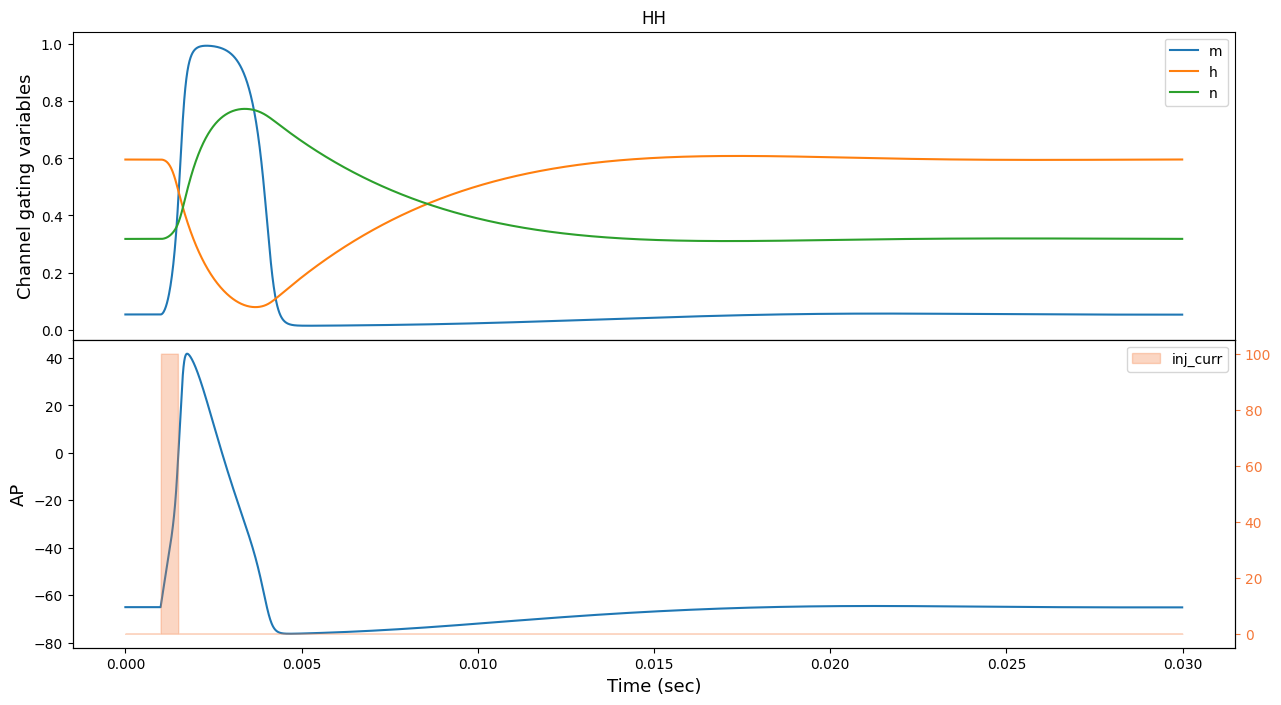

In [3]:
nrnmfb.I_amp = 100
nrnmfb.solve()

nrnhh.I_amp = 100
nrnhh.solve()

### MFB
nFig = 2
figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True, facecolor='#ffffff')
figure.subplots_adjust(hspace=0.0)
labelfontsize = 13
for k,v in nrnmfb.sol.items():
    if k == 'V':
        ax[1].plot(nrnmfb.T, v)
        ax[1].set_ylabel('AP', fontsize=labelfontsize)
        ax[1].set_xlabel('Time (sec)', fontsize=labelfontsize)
        
        ax[1].plot(nrnmfb.T, [-80.789]*len(nrnmfb.T))
        ax[1].plot(nrnmfb.T, [-81.25]*len(nrnmfb.T))
        #ax[1].set_ylim(-82,-80)
        ax[1].grid()
        #ax[1].legend(facecolor='white', framealpha=0.8)
        
        axt2 = ax[1].twinx()
        inj = list(map(nrnmfb.I_ext, nrnmfb.T))
        axt2.tick_params(axis='y', which='both', colors=colors[3])
        axt2.fill_between(nrnmfb.T, inj, 0, color=colors[3], alpha=0.3, label='inj_curr')
        axt2.legend()
        
    else:
        ax[0].plot(nrnmfb.T, v, label=k)
        ax[0].set_ylabel('Channel gating variables', fontsize=labelfontsize)
        ax[0].legend(facecolor='white')
        ax[0].set_title('MFB')
        
### HH 
nFig = 2
figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True, facecolor='#ffffff')
figure.subplots_adjust(hspace=0.0)
labelfontsize = 13

for k,v in nrnhh.sol.items():
    if k == 'V':
        ax[1].plot(nrnhh.T, v)
        ax[1].set_ylabel('AP', fontsize=labelfontsize)
        ax[1].set_xlabel('Time (sec)', fontsize=labelfontsize)
        #ax[1].legend(facecolor='white', framealpha=0.8)
        
        axt1 = ax[1].twinx()
        inj = list(map(nrnhh.I_ext, nrnhh.T))
        axt1.tick_params(axis='y', which='both', colors=colors[3])
        axt1.fill_between(nrnmfb.T, inj, 0, color=colors[3], alpha=0.3, label='inj_curr')
        axt1.legend()

    else:
        ax[0].plot(nrnhh.T, v, label=k)
        ax[0].set_ylabel('Channel gating variables', fontsize=labelfontsize)
        ax[0].legend(facecolor='white')
        ax[0].set_title('HH')

In [4]:
np.savetxt('AP.dat', np.array([nrnmfb.T, nrnmfb.sol['V']]).T, fmt=['%0.5f', '%0.2f'])

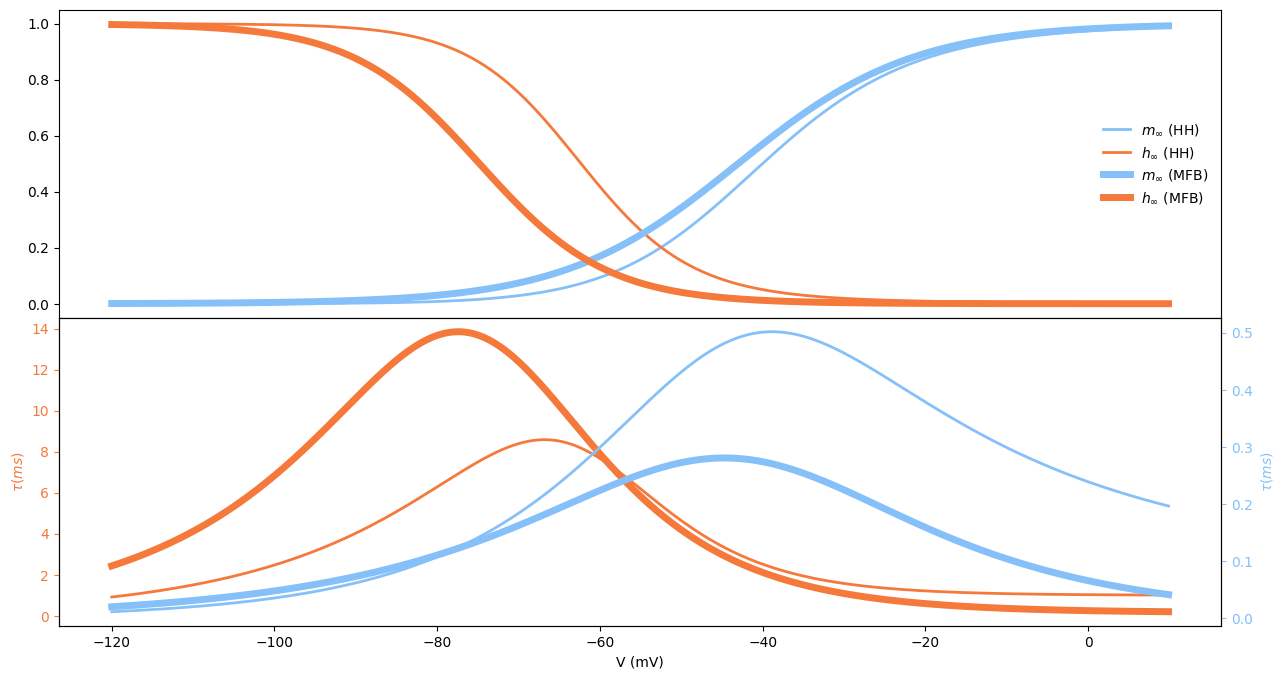

In [5]:
Varr = np.arange(-120, 10, 0.1)
amMF = nrnmfb.alpha_m(Varr)
bmMF = nrnmfb.beta_m(Varr)
ahMF = nrnmfb.alpha_h(Varr)
bhMF = nrnmfb.beta_h(Varr)

am = nrnhh.alpha_m(Varr)
bm = nrnhh.beta_m(Varr)
ah = nrnhh.alpha_h(Varr)
bh = nrnhh.beta_h(Varr)

nFig = 2
figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True, facecolor='#ffffff')
figure.subplots_adjust(hspace=0.0)

ax[0].plot(Varr, am/(am+bm), color=colors[6], lw=2, label=r'$m_\infty$ (HH)')
ax[0].plot(Varr, ah/(ah+bh), color=colors[3], lw=2, label=r'$h_\infty$ (HH)')

ax[0].plot(Varr, amMF/(amMF+bmMF), color=colors[6], lw=5, label=r'$m_\infty$ (MFB)')
ax[0].plot(Varr, ahMF/(ahMF+bhMF), color=colors[3], lw=5, label=r'$h_\infty$ (MFB)')

ax[1].plot(Varr, 1/(ah+bh), color=colors[3], lw=2, label=r'$h_\infty$ (HH)')
ax[1].plot(Varr, 1/(ahMF+bhMF), color=colors[3], lw=5, label=r'$h_\infty$ (MFB)')
ax[1].set_ylabel(r'$\tau (ms)$', color=colors[3])
ax[1].tick_params(colors=colors[3])

axt = ax[1].twinx()
axt.plot(Varr, 1/(am+bm), color=colors[6], lw=2, label=r'$m_\infty$ (HH)')
axt.plot(Varr, 1/(amMF+bmMF), color=colors[6], lw=5, label=r'$m_\infty$ (MFB)')
axt.set_ylabel(r'$\tau (ms)$', color=colors[6])
axt.tick_params(axis='y', which='both', colors=colors[6])


ax[1].tick_params(axis='x', which='both', colors='black')
ax[0].legend(frameon=False)
#ax[1].legend(frameon=False)
#axt.legend(frameon=False)
ax[1].set_xlabel('V (mV)')
plt.show()
#showAllColors(colors)

# Generating AP protocols with different ISI 

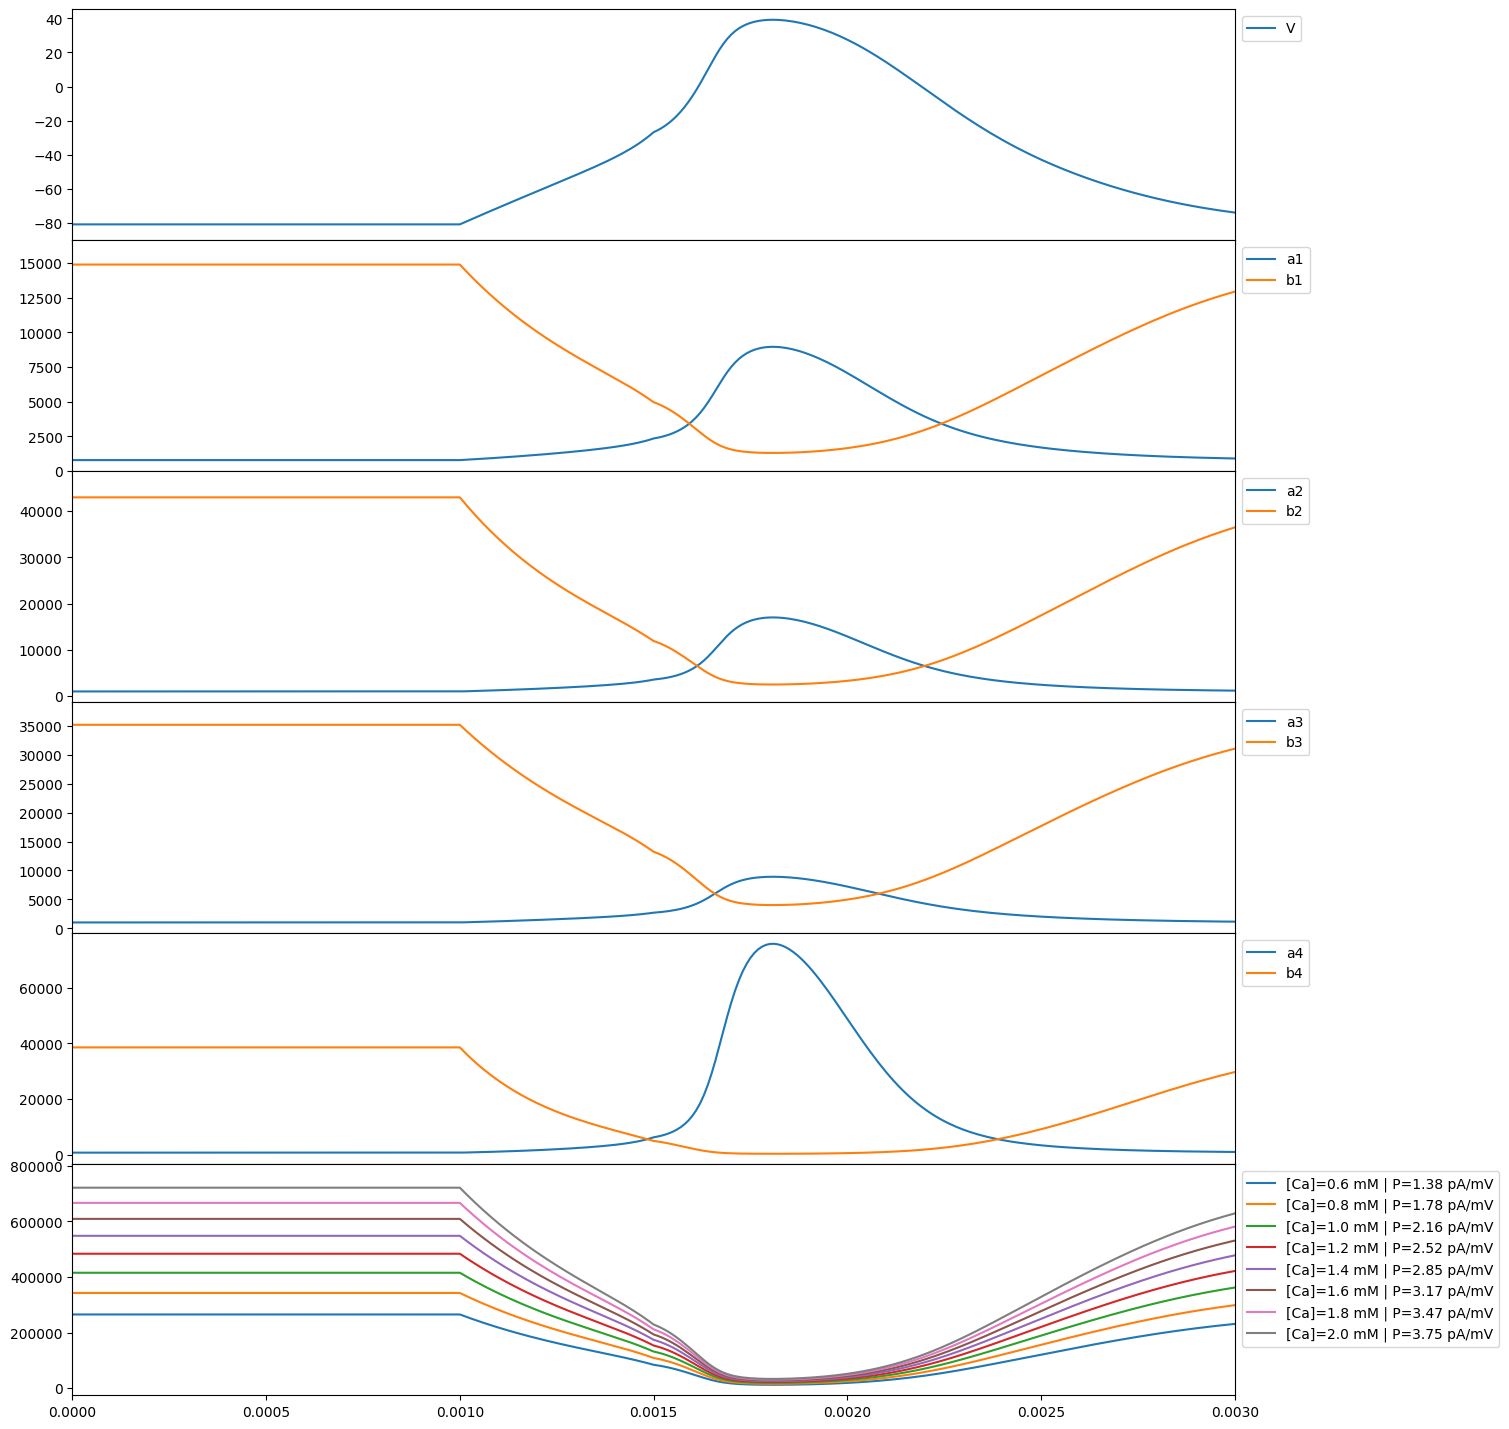

In [6]:
sol = list(nrnmfb.sol.values())
T, V = getProtocolV(sol, isi=20, nap=10)

nFig = 6
figure, ax = plt.subplots(nFig, figsize=(15, 3*nFig), sharex=True)
figure.subplots_adjust(hspace=0.)

ax[0].plot(T, V, label='V')

ax[1].plot(T, a1(V), label='a1')
ax[1].plot(T, b1(V), label='b1')
ax[2].plot(T, a2(V), label='a2')
ax[2].plot(T, b2(V), label='b2')
ax[3].plot(T, a3(V), label='a3')
ax[3].plot(T, b3(V), label='b3')
ax[4].plot(T, a4(V), label='a4')
ax[4].plot(T, b4(V), label='b4')

for Ca in np.arange(0.6, 2.01, 0.2):
    P, PQ = 9.2/(1 + 5.6/Ca), 9.2/(1 + 5.6/Ca)*1.55
    #print("%0.1f  %0.2f  %0.2f" % (Ca, P, PQ))
    ax[5].plot(T, CaFlux(P,V), label='[Ca]='+str("{:1.1f}".format(Ca))+' mM | P='+str("{:.2f}".format(PQ))+' pA/mV')

for x in ax:
    x.legend(loc='upper left', facecolor='white', framealpha=0.8, bbox_to_anchor=(1,1))
    x.set_xlim(min(T), 0.003)#max(T))

## Generate VDCC rate files

/home/nishant/lab/MFB/mcell/vdcc_dat/VDCC_Ca_20ms_N10_2.0mM.dat
/home/nishant/lab/MFB/mcell/vdcc_dat/VDCC_Ca_100ms_N10_2.0mM.dat


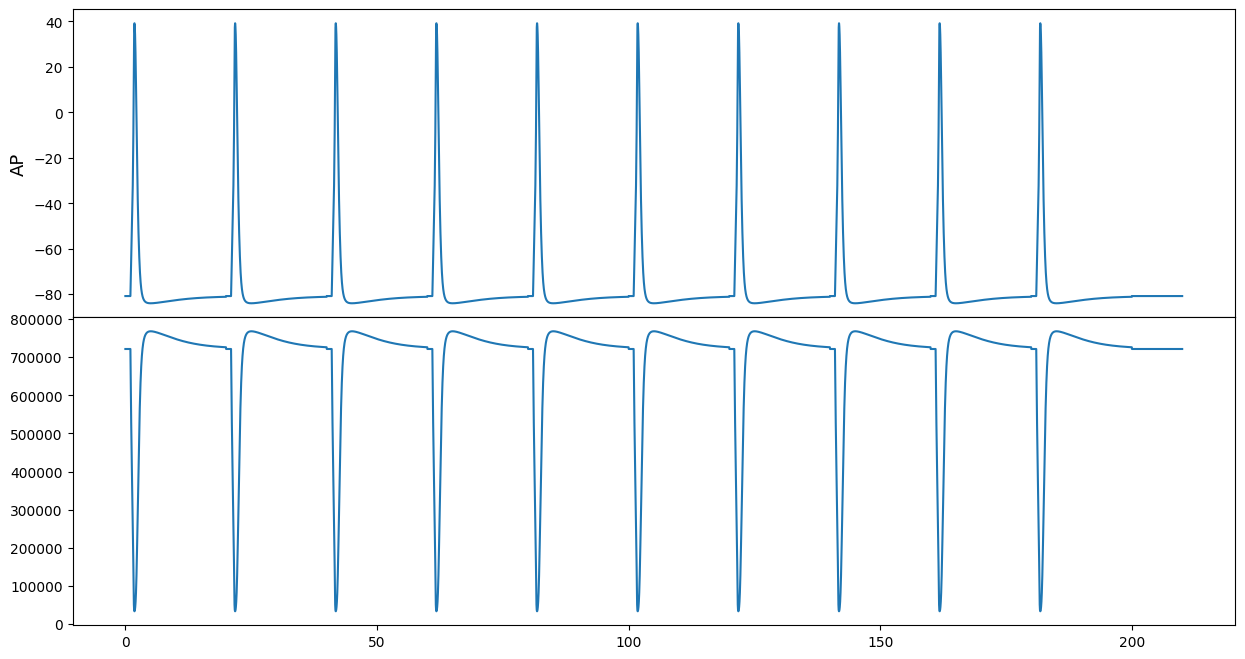

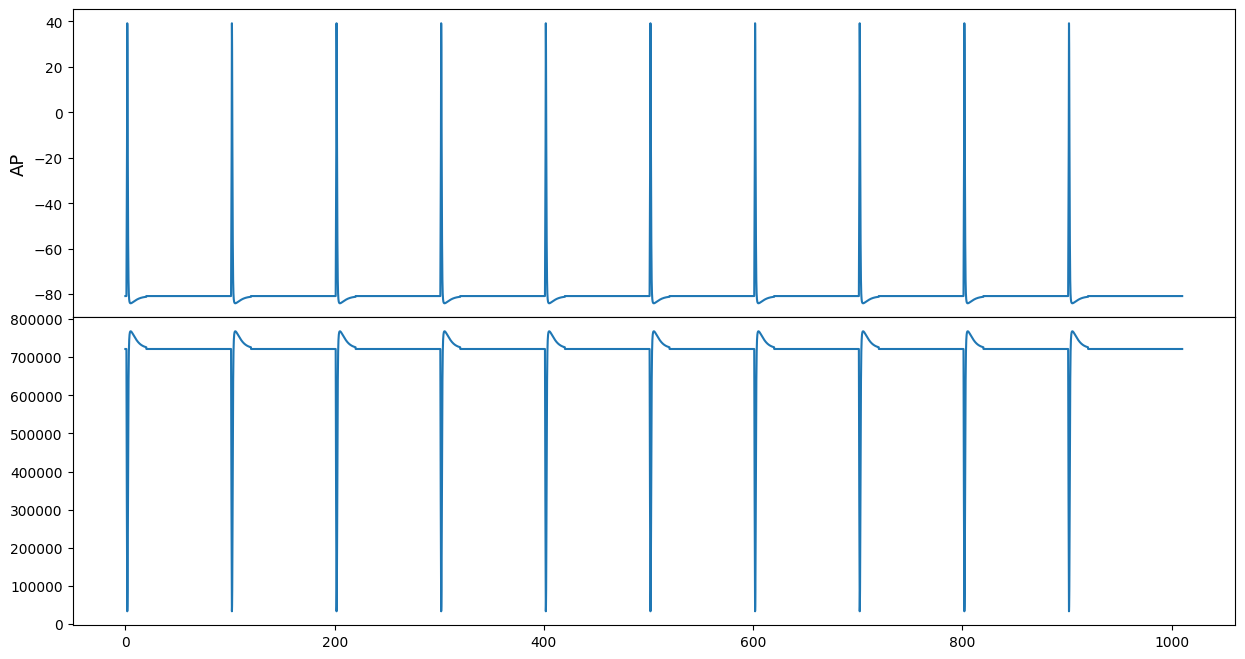

In [7]:
ISI = list(range(20, 101, 80))# + list(range(100, 201, 20))  + [300, 400, 500]# ms
N = [10] # number of action potentials

plot = True
save = False
for isi, n in product(ISI, N): # in ms

    T, V = getProtocolV(sol, isi=isi, nap=n)

    ## To show Figures
    if plot:
        nFig = 2
        figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True)
        figure.subplots_adjust(hspace=0.)

        Ca = 2.0
        P, PQ = 9.2/(1 + 5.6/Ca), 9.2/(1 + 5.6/Ca)*1.55
        #print("%0.1f  %0.2f  %0.2f" % (Ca, P, PQ))

        ax[0].plot(T*1000, V)
        ax[0].set_xlabel('Time (ms)', fontsize=labelfontsize)
        ax[0].set_ylabel('AP', fontsize=labelfontsize)

        ax[1].plot(T*1000, CaFlux(P,V), label='[Ca]='+str("{:1.1f}".format(Ca))+' mM | P='+str("{:.2f}".format(PQ))+' pA/mV')

    ## Saving to file
    dir = '/home/nishant/lab/MFB/mcell/vdcc_dat/'
    if save:
        np.savetxt(dir+f"VDCC_C01_{isi}ms_N{n}.dat", np.array([T, a1(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C10_{isi}ms_N{n}.dat", np.array([T, b1(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C12_{isi}ms_N{n}.dat", np.array([T, a2(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C21_{isi}ms_N{n}.dat", np.array([T, b2(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C23_{isi}ms_N{n}.dat", np.array([T, a3(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C32_{isi}ms_N{n}.dat", np.array([T, b3(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C34_{isi}ms_N{n}.dat", np.array([T, a4(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C43_{isi}ms_N{n}.dat", np.array([T, b4(V)]).T, fmt=['%0.5f','%0.1f'])
        
    for Ca in [2.0]:
        P, PQ, my = 9.2/(1 + 5.6/Ca), 9.2/(1 + 5.6/Ca)*1.55, 9.2/(1 + 5.6/Ca)*1.25
        fname = dir+f"VDCC_Ca_{isi}ms_N{n}_{Ca:.1f}mM.dat"
        print(fname)
        if save:
            np.savetxt(fname, np.array([T, CaFlux(P,V)]).T, fmt=['%0.5f', '%0.1f'])

## VDCC dat files for multi-burst AP

In [8]:
def getProtocolV(sol, isi, nap, bg=0, nb=1):
    #print(isi, bg, nb, nap)
    assert(isi >= 20), "ISI must be >= 20"

    tstep = 1e-5
    ti, tf = 0, ((nb-1)*((nap-1)*isi + bg) + nap*isi + 10.0 + tstep)*1e-3
    T = np.arange(ti, tf, tstep)

    Vtemp = sol[0][:2000] # 100 points = 1 ms

    V = np.array([])
    for nbb in range(nb):
        for i in range(nap):
            temp = np.full((isi-20)*100, -8.07890166e+01)
            V = np.concatenate((V, Vtemp, temp))

        if nbb != nb-1:
            bgap = np.full((bg-isi)*100, -8.07890166e+01)
            V = np.concatenate((V, bgap))
        
    temp = np.full((10)*100+1, -8.07890166e+01)
    V = np.concatenate((V, temp))
    #print(tf, T.shape, V.shape)
    
    return T, V

getProtocolV(sol, isi=20, bg=65, nb=4, nap=4);

/home/nishant/lab/MFB/mcell/vdcc_dat/VDCC_Ca_20ms_N4_bgap_65_nburst_4_2.0mM.dat
/home/nishant/lab/MFB/mcell/vdcc_dat/VDCC_Ca_20ms_N4_bgap_190_nburst_4_2.0mM.dat


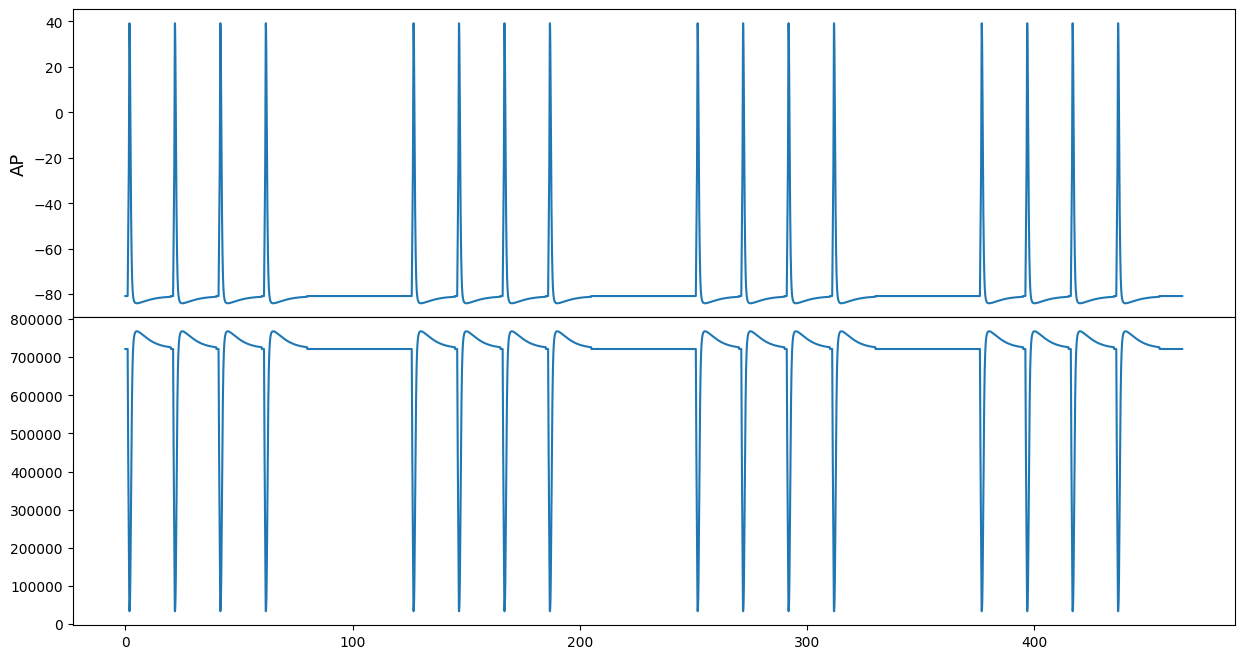

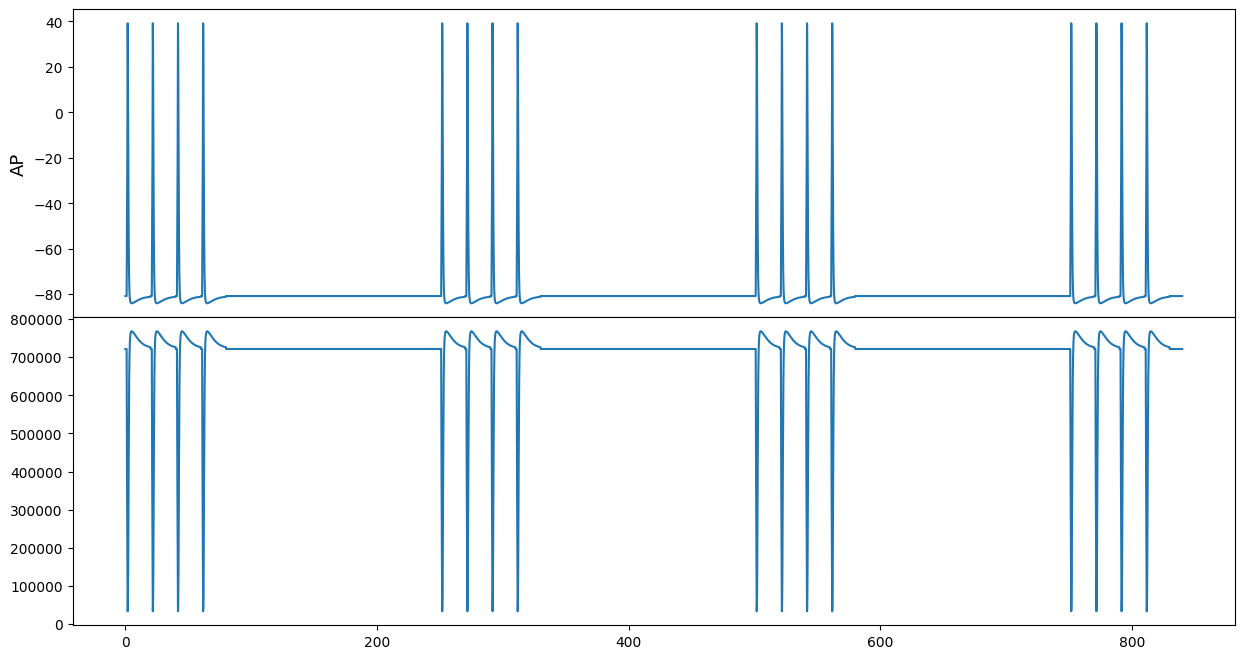

In [9]:
ISI = list(range(20, 101, 100))# + list(range(100, 201, 20))  + [300, 400, 500]# ms
bisi = [125, 250]
bgap = [bi-60 for bi in bisi] # ms
nburst = [4] # number of bursts
nAP = [4] # number of action potentials

plot = True
save = False
for isi, bg, nb, nap in product(ISI, bgap, nburst, nAP): # in ms
    T, V = getProtocolV(sol, isi=isi, nap=nap, bg=bg, nb=nb)

    ## To show Figures
    if plot:
        nFig = 2
        figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True)
        figure.subplots_adjust(hspace=0.)

        Ca = 2.0
        P, PQ = 9.2/(1 + 5.6/Ca), 9.2/(1 + 5.6/Ca)*1.55
        #print("%0.1f  %0.2f  %0.2f" % (Ca, P, PQ))

        ax[0].plot(T*1000, V)
        ax[0].set_xlabel('Time (ms)', fontsize=labelfontsize)
        ax[0].set_ylabel('AP', fontsize=labelfontsize)

        ax[1].plot(T*1000, CaFlux(P,V), label='[Ca]='+str("{:1.1f}".format(Ca))+' mM | P='+str("{:.2f}".format(PQ))+' pA/mV')

    ## Saving to file
    dir = '/home/nishant/lab/MFB/mcell/vdcc_dat/'
    if save:
        np.savetxt(dir+f"VDCC_C01_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}.dat", np.array([T, a1(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C10_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}.dat", np.array([T, b1(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C12_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}.dat", np.array([T, a2(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C21_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}.dat", np.array([T, b2(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C23_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}.dat", np.array([T, a3(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C32_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}.dat", np.array([T, b3(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C34_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}.dat", np.array([T, a4(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C43_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}.dat", np.array([T, b4(V)]).T, fmt=['%0.5f','%0.1f'])
        
    for Ca in [2.0]:
        P, PQ, my = 9.2/(1 + 5.6/Ca), 9.2/(1 + 5.6/Ca)*1.55, 9.2/(1 + 5.6/Ca)*1.25
        fname = dir+f"VDCC_Ca_{isi}ms_N{nap}_bgap_{bg}_nburst_{nb}_{Ca:.1f}mM.dat"
        print(fname)
        if save:
            np.savetxt(fname, np.array([T, CaFlux(P,V)]).T, fmt=['%0.5f', '%0.1f'])

FileNotFoundError: [Errno 2] No such file or directory: '/home/nishant/lab/MFB/mcell/vdcc_dat/VDCC_C01_ISI_20_nAP_4_bISI_125_nB_5.dat'

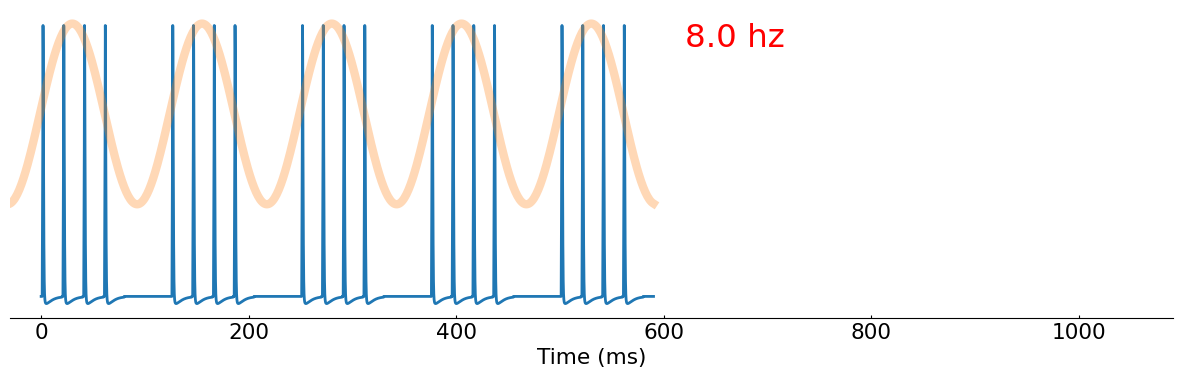

In [10]:
ISI = [20] # ms
nAP = [4] # number of action potentials
bISI = [125, 250]
nburst = [5] # number of bursts

plot = True
save = True
for isi, bisi, nb, nap in product(ISI, bISI, nburst, nAP): # in ms
    bgap = bisi - (nap-1)*isi
    T, V = getProtocolV(sol, isi=isi, nap=nap, bg=bgap, nb=nb)
    
    ## To show Figures
    if plot:
        nFig = 1
        f, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True)
        f.subplots_adjust(hspace=0.)

        Ca = 2.0
        P, PQ = 9.2/(1 + 5.6/Ca), 9.2/(1 + 5.6/Ca)*1.55
        #print("%0.1f  %0.2f  %0.2f" % (Ca, P, PQ))

        freq = 1000/bisi
        ax.plot(T*1000, V, label=f'{1000/(bg+60)} hz', lw=2)
        ax.set_xlabel('Time (ms)', fontsize=labelfontsize*1.2)
        #ax.set_ylabel('AP', fontsize=labelfontsize*1.2)
        ax.tick_params(axis=u'x', which=u'both', length=2, direction='in', labelsize=labelfontsize*1.2)
        ax.text(620, 30, f'{freq} hz', fontsize=labelfontsize*1.8, color='r')
        
        TT = np.arange(-50, T[-1]*1000)
        ax.plot(TT, 40*np.sin(2*np.pi*freq*TT/1000  + (0.25-30/bisi)*2*np.pi), lw=6, alpha=0.3)
        ax.set_xlim(-30,1090)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.axes.yaxis.set_visible(False)

        #ax[1].plot(T*1000, CaFlux(P,V), label='[Ca]='+str("{:1.1f}".format(Ca))+' mM | P='+str("{:.2f}".format(PQ))+' pA/mV')

    ## Saving to file
    dir = '/home/nishant/lab/MFB/mcell/vdcc_dat/'
    if save:
        np.savetxt(dir+f"VDCC_C01_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}.dat", np.array([T, a1(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C10_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}.dat", np.array([T, b1(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C12_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}.dat", np.array([T, a2(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C21_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}.dat", np.array([T, b2(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C23_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}.dat", np.array([T, a3(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C32_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}.dat", np.array([T, b3(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C34_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}.dat", np.array([T, a4(V)]).T, fmt=['%0.5f','%0.1f'])
        np.savetxt(dir+f"VDCC_C43_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}.dat", np.array([T, b4(V)]).T, fmt=['%0.5f','%0.1f'])
        
    for Ca in [2.0]:
        P, PQ, my = 9.2/(1 + 5.6/Ca), 9.2/(1 + 5.6/Ca)*1.55, 9.2/(1 + 5.6/Ca)*1.25
        fname = dir+f"VDCC_Ca_ISI_{isi}_nAP_{nap}_bISI_{bisi}_nB_{nb}_{Ca:.1f}mM.dat"
        print(fname)
        if save:
            np.savetxt(fname, np.array([T, CaFlux(P,V)]).T, fmt=['%0.5f', '%0.1f']) # time in sec

# Extra stuff for testing 

### Varying VDCC flux

In [ ]:
dir = '/home/nishant/lab/MFB/mcell/vdcc_dat/'

Ca = 2.0
n=2
for nV in [2,5,10,15,20,30,40,50]:
    P, PQ, my = 9.2/(1 + 5.6/Ca)*nV, 9.2/(1 + 5.6/Ca)*1.55, 9.2/(1 + 5.6/Ca)*1.25
    fname = dir+"VDCC_Ca_{0:d}ms_N{1:d}_{2:.1f}mM_nVDCC_{3:d}.dat".format(isi,n,Ca,nV)
    print(fname)
    #np.savetxt(fname, np.array([T, CaFlux(P,V)]).T, fmt=['%0.5f', '%0.1f'])
    plt.plot(T, CaFlux(P,V).T)

## Externam calcium concentration

In [ ]:
Ca = np.arange(0.1, 3.01, 0.1)
P, PQ, my = 9.2/(1 + 5.6/Ca), 9.2/(1 + 5.6/Ca)*1.55, 9.2/(1 + 5.6/Ca)*1.25

print('Ca\tP\tPQ\t my')
for a,b,c,d in zip(Ca, P, PQ, my):
    print("%0.1f\t%0.2f\t%0.2f\t %0.2f" % (a, b, c, d))
    
plt.plot(Ca, P, 'o-', label="P")
plt.plot(Ca, PQ, 'o-', label="PQ")
plt.plot(Ca, my, 'o-', label="my")
plt.legend()
plt.show()